In [ ]:
###################
#  LSTM UNBALANCE
##################
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd
import numpy as np
from tqdm import tqdm
import gc
import warnings
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import class_weight

warnings.filterwarnings('ignore')

# ------------------------------------------------------------------------------
# 1. INIT & TIME CONVERT
# ------------------------------------------------------------------------------
print("\n[1/4] Đang đọc file Parquet và chuẩn bị không gian...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)
df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
drop_cols = exclude_cols

df['starttime'] = pd.to_numeric(df['starttime'], errors='coerce')
df['starttime'] = pd.to_datetime(df['starttime'], unit='s')

# ------------------------------------------------------------------------------
# 2. HANDLE CATEGORICAL (ONE-HOT CHO DEEP LEARNING)
# ------------------------------------------------------------------------------
feature_cols = [c for c in df.columns if c not in drop_cols]
cat_cols = df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

# ------------------------------------------------------------------------------
# 3. DEFINE FEATURE TYPES
# ------------------------------------------------------------------------------
keep_org_cols = [
    'isworkhour', 'isafterhour', 'isweekend', 'isweekendafterhour',
    'pc', 'n_logon', 'n_days', 'n_concurrent_sessions',
    'start_with', 'end_with', 'ses_start', 'ses_end',
    'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin',
    'O', 'C', 'E', 'A', 'N'
]
cat_binary_cols = [c for c in keep_org_cols if c in df.columns]

# Khởi tạo cột Numeric (Bỏ các cột nhị phân/hạng mục ra)
numeric_cols = [c for c in df.columns if c not in (cat_binary_cols + drop_cols)]

# ------------------------------------------------------------------------------
# 4. TIME SPLIT (CHIA TRƯỚC KHI ONE-HOT ĐỂ CHỐNG LEAKAGE)
# ------------------------------------------------------------------------------
print("\n[3/5] TIME SPLIT & ONE-HOT ENCODING (LEAKAGE-FREE)...")

df = df.sort_values(by='starttime').reset_index(drop=True)

n = len(df)
train_end = int(n * 0.64)
val_end = int(n * 0.80)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

# --- ONE-HOT ĐỘC LẬP TỪNG TẬP ---
cat_cols = df_train.select_dtypes(include=["object", "category"]).columns.tolist()

df_train = pd.get_dummies(df_train, columns=cat_cols, drop_first=True)
df_val   = pd.get_dummies(df_val, columns=cat_cols, drop_first=True)
df_test  = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

# 🔥 BÍ KÍP ALIGN: Khớp cột Val và Test theo đúng form của Train (thiếu thì điền 0)
df_train, df_val = df_train.align(df_val, join='left', axis=1, fill_value=0)
df_train, df_test = df_train.align(df_test, join='left', axis=1, fill_value=0)

# Cứu hộ dọn dẹp các giá trị lỗi có thể sinh ra
for d in [df_train, df_val, df_test]:
    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    d.fillna(0, inplace=True)

# ------------------------------------------------------------------------------
# 5. PREPROCESSING SÂU: LỌC RÁC, TRỊ SKEW & SCALING
# ------------------------------------------------------------------------------
print("\n[4/5] PREPROCESSING...")

# --- 5.0 TỰ ĐỘNG PHÂN LOẠI CỘT BẰNG CODE CỦA BẠN ---
# Loại bỏ các cột định danh ra khỏi quá trình duyệt
skip_cols = drop_cols + ['starttime', 'endtime', 'user', 'sessionid']
scan_cols = [c for c in df_train.columns if c not in skip_cols]

# Nhận diện cột Binary 
# binary_cols = [c for c in scan_cols if set(df_train[c].dropna().unique()) <= {0, 1, 0.0, 1.0, True, False}]
binary_cols = [c for c in scan_cols if df_train[c].nunique() <= 5]

# Cột Numeric là phần còn lại
numeric_cols = [c for c in scan_cols if c not in binary_cols]

print(f"  -> Nhận diện tự động: {len(binary_cols)} cột Binary | {len(numeric_cols)} cột Numeric")

# --- 5.1 XÓA ZERO VARIANCE ---
valid_numeric = [c for c in numeric_cols if df_train[c].std() > 0]
dead_cols = list(set(numeric_cols) - set(valid_numeric))

for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
numeric_cols = valid_numeric

# --- 5.2 XÓA CỘT SPARSE (BẢO VỆ TIỀN TỐ) ---
sparse_threshold = 0.99
potential_sparse = [c for c in numeric_cols if (df_train[c] == 0).mean() > sparse_threshold]
protected_prefixes = ('n_', 'file_', 'email_', 'http_', 'usb', 'logon')
sparse_to_drop = [c for c in potential_sparse if not c.startswith(protected_prefixes)]

for d in [df_train, df_val, df_test]:
    d.drop(columns=sparse_to_drop, inplace=True, errors='ignore')
numeric_cols = [c for c in numeric_cols if c not in sparse_to_drop]

# --- 5.3 SKEW TREATMENT (NUNIQUE > 10) ---
# 🔥 BÍ KÍP REFINE SKEW CỦA BẠN 
skewed_cols = [c for c in numeric_cols if (df_train[c].nunique() > 10) and (abs(df_train[c].skew()) > 3)]

def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))

for col in skewed_cols:
    df_train[col] = signed_log(df_train[col])
    df_val[col]   = signed_log(df_val[col])
    df_test[col]  = signed_log(df_test[col])

# --- 5.4 STANDARD SCALER CHO TOÀN BỘ NUMERIC ---
if len(numeric_cols) > 0:
    sc = StandardScaler()
    df_train[numeric_cols] = sc.fit_transform(df_train[numeric_cols])
    df_val[numeric_cols]   = sc.transform(df_val[numeric_cols])
    df_test[numeric_cols]  = sc.transform(df_test[numeric_cols])

# ------------------------------------------------------------------------------
# 6. CHỐT HẠ FEATURE
# ------------------------------------------------------------------------------
# Chốt lại danh sách cột theo đúng thứ tự đang nằm trong df_train
feature_cols = [c for c in df_train.columns if c not in skip_cols]

print(f"✅ Đã chốt hạ danh sách đầu vào cho Model: {len(feature_cols)} features hợp lệ.")

# ==============================================================================
# 4️⃣ TẠO TENSOR 3D BẰNG SLIDING WINDOW (Cho Deep Learning)
# ==============================================================================
print("\n[4/5] Đang cuộn dữ liệu thành Tensor 3D...")

def create_sliding_windows_3D(df_subset, window_size=3):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []

    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        group_len = len(group)
        if group_len < window_size: continue
            
        features = group[feature_cols].values
        labels   = group['insider'].values

        for i in range(group_len - window_size + 1):
            window_features = features[i : i + window_size] 
            window_label = labels[i + window_size - 1]
            #window_label = np.max(labels[i : i + window_size])
            X_list.append(window_features)
            y_list.append(window_label)
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 4
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE)

# --- BÁO CÁO KIỂM TOÁN (AUDIT REPORT) 2: SHAPE 3D & PHÂN BỔ NHÃN SAU WINDOW ---
print("\n" + "-"*60)
print("📦 BÁO CÁO KIỂM TOÁN TENSOR 3D (SAU SLIDING WINDOW)")
print("-"*60)
print(f"Tập TRAIN Tensor: {X_train.shape}")
print(f"  > Giải thích: {X_train.shape[0]:,} (Mẫu) x {X_train.shape[1]} (Time steps) x {X_train.shape[2]} (Đặc trưng gốc/bước)")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_train, return_counts=True)))}")

print(f"\nTập VAL Tensor: {X_val.shape}")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_val, return_counts=True)))}")

print(f"\nTập TEST Tensor: {X_test.shape}")
print(f"  > Phân bổ nhãn: {dict(zip(*np.unique(y_test, return_counts=True)))}")
print("-"*60)

# =====================================================
# 5️⃣ XÂY DỰNG VÀ HUẤN LUYỆN LSTM ĐA LỚP
# =====================================================
from tensorflow.keras.layers import Masking
print(f"\n[TRAINING] Huấn luyện Baseline LSTM Multiclass (Train: {len(y_train)} mẫu gốc)...")
T = X_train.shape[1]
F = X_train.shape[2]

model = Sequential([
    # Tầng 1: 128 units để hấp thụ trọn vẹn 120 features
    LSTM(128, return_sequences=True, input_shape=(T, F)),
    Dropout(0.3), # Tăng chút Dropout vì mạng lớn hơn
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    #Dense(64, activation='relu'),
    #BatchNormalization(),
    # Tầng Dense 2: Nén thông tin trước khi phân loại
    Dense(32, activation='relu'),
    BatchNormalization(),
    # Đầu ra 4 nodes tương ứng 4 lớp, dùng hàm Softmax
    Dense(4, activation='softmax')
])

# Vì nhãn là số nguyên (0,1,2,3), ta dùng sparse_categorical_crossentropy
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

#reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

custom_weight = {
    0: 1.0,
    1: 20.0,
    2: 30.0,
    3: 25.0
}
start_time = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, # Để 30 epoch, EarlyStopping sẽ tự ngắt nếu hội tụ sớm
    batch_size=1024, # Batch size lớn để train nhanh trên dữ liệu khổng lồ
    class_weight=custom_weight,
    callbacks=[early_stop],
    verbose=1
)
print(f"✅ Hoàn thành Huấn luyện! Thời gian: {time.time() - start_time:.2f} giây.")

# =====================================================
# 6️⃣ INFERENCE VÀ ĐÁNH GIÁ (ARGMAX CƠ BẢN)
# =====================================================
print("\n[INFERENCE] Đang dự đoán trên tập Test...")
prob_test = model.predict(X_test)

# Không dùng threshold, phó mặc hoàn toàn cho Argmax
final_preds = np.argmax(prob_test, axis=1)

print("\n========== CLASSIFICATION REPORT ==========")
print(classification_report(y_test, final_preds, digits=4, zero_division=0))

cm = confusion_matrix(y_test, final_preds, normalize="true")
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=["Benign","Scenario 1","Scenario 2","Scenario 3"], 
            yticklabels=["Benign","Scenario 1","Scenario 2","Scenario 3"])
plt.title("Confusion Matrix - Unbalance LSTM")
plt.xlabel("Predict")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# --- BIỂU ĐỒ LEARNING CURVE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', color='blue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='darkorange')
axes[0].set_title('LSTM: Loss', fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.7)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange')
axes[1].set_title('LSTM: Accuracy', fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
#################################################################
# LSTM PHÂN TẦNG BINARY -> MULTICLASS
#################################################################

import pandas as pd
import numpy as np
import gc, random, os, time
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import warnings
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# --- HÀM VẼ BIỂU ĐỒ LEARNING CURVE ---
def plot_learning_curves(history, title_prefix):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # Biểu đồ Loss
    ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
    ax[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
    ax[0].set_title(f'{title_prefix} - Loss Curve', fontweight='bold')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True, linestyle=':', alpha=0.6)
    
    # Biểu đồ Accuracy
    acc_key = 'accuracy' if 'accuracy' in history.history else 'acc'
    val_acc_key = 'val_accuracy' if 'val_accuracy' in history.history else 'val_acc'
    
    ax[1].plot(history.history[acc_key], label='Train Acc', color='blue')
    ax[1].plot(history.history[val_acc_key], label='Val Acc', color='orange')
    ax[1].set_title(f'{title_prefix} - Accuracy Curve', fontweight='bold')
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# ==============================================================================
# 1. ĐỌC DATA & TIỀN XỬ LÝ
# ==============================================================================
print("\n[1/4] Đang đọc file, chia tập và Scale dữ liệu...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))

df_train, df_val, df_test = split_user_time_multiclass(df)

dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

categorical_cols = ['pc', 'start_with', 'end_with', 'ses_start', 'ses_end', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 2. TẠO TENSOR 3D BẰNG SLIDING WINDOW
# ==============================================================================
print("\n[2/4] Đang cuộn dữ liệu thành Tensor 3D (Nhãn Max Label)...")

def create_sliding_windows_3D(df_subset, window_size=5):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        features, labels = group[feature_cols].values, group['insider'].values
        for i in range(len(group) - window_size + 1):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val     = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test   = create_sliding_windows_3D(df_test, WINDOW_SIZE)

N_train, T, F = X_train.shape
del df_train, df_val, df_test; gc.collect()

def build_bilstm(is_binary=False):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=(T,F)), Dropout(0.3),
        LSTM(64, return_sequences=False), Dropout(0.3),
        #Dense(64, activation='relu'),
        Dense(32, activation='relu'),  BatchNormalization()
    ])
    if is_binary:
        model.add(Dense(1, activation='sigmoid'))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005), loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'])
    else:
        model.add(Dense(4, activation='softmax'))
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy'])
    return model


# ==============================================================================
# 3. TẦNG 1: BINARY GATEKEEPER
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN BINARY GATEKEEPER")
print("="*75)

y_train_t1, y_val_t1 = (y_train > 0).astype(int), (y_val > 0).astype(int)
class_weight_t1 = {0: 1.0, 1: 300.0}

start_time_t1 = time.time()
model_t1 = build_bilstm(is_binary=True)
history_t1 = model_t1.fit(
    X_train, y_train_t1, validation_data=(X_val, y_val_t1), class_weight=class_weight_t1, 
    epochs=100, batch_size=512, verbose=1,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)]
)
total_time_t1 = time.time() - start_time_t1
# Vẽ biểu đồ Tầng 1
plot_learning_curves(history_t1, "TẦNG 1 (Binary)")

# --- DÒ TÌM THRESHOLD TẦNG 1 ---
print("\n🔍 Đang ép Threshold Tầng 1 (Trừ hao Domain Shift cho tập Test)...")
probs_val_t1 = model_t1.predict(X_val).flatten()

best_threshold_t1 = 0.01 
best_recall, best_fpr = 0.0, 1.0
TARGET_RECALL_VAL = 0.80

for thresh in np.arange(0.99, 0.00, -0.01):
    preds_tmp = (probs_val_t1 >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_t1, preds_tmp, labels=[0, 1]).ravel()
    
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    if recall >= TARGET_RECALL_VAL:
        best_threshold_t1 = thresh
        best_recall = recall
        best_fpr = fpr
        break 

if best_threshold_t1 > 0.20:
    best_threshold_t1 = 0.15 

THRESHOLD_T1 = best_threshold_t1
print(f"-> 🏆 Chốt Threshold Tầng 1 = {THRESHOLD_T1:.2f}")

# ==============================================================================
# 4. CHUẨN BỊ DATA & TRAIN TẦNG 2
# ==============================================================================
print("\n" + "="*75)
print("🔵 CHUẨN BỊ DỮ LIỆU VÀ TRAIN TẦNG 2 (TẠO RANH GIỚI MỎ NEO BENIGN)")
print("="*75)

probs_train_t1 = model_t1.predict(X_train).flatten()
attack_mask = (y_train > 0)
hard_mask = (y_train == 0) & (probs_train_t1 >= THRESHOLD_T1)
benign_indices = np.where(y_train == 0)[0]
np.random.shuffle(benign_indices)
random_mask = np.zeros_like(y_train, dtype=bool)
random_mask[benign_indices[:int(0.3 * len(benign_indices))]] = True

mask_train_t2 = attack_mask | hard_mask | random_mask
X_train_t2, y_train_t2 = X_train[mask_train_t2], y_train[mask_train_t2]

probs_val_t1_t2 = model_t1.predict(X_val).flatten()
hard_val_mask = (y_val == 0) & (probs_val_t1_t2 >= THRESHOLD_T1)
benign_val_idx = np.where(y_val == 0)[0]
np.random.shuffle(benign_val_idx)
random_val_mask = np.zeros_like(y_val, dtype=bool)
random_val_mask[benign_val_idx[:int(0.3 * len(benign_val_idx))]] = True

val_mask_t2 = (y_val > 0) | hard_val_mask | random_val_mask
X_val_t2, y_val_t2 = X_val[val_mask_t2], y_val[val_mask_t2]

class_weight_t2 = {0: 1.0, 1: 5.0, 2: 150.0, 3: 100.0} 
y_train_t2_onehot = tf.keras.utils.to_categorical(y_train_t2, num_classes=4)
y_val_t2_onehot   = tf.keras.utils.to_categorical(y_val_t2, num_classes=4)

start_time_t2 = time.time()
model_t2 = build_bilstm(is_binary=False)
es_t2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history_t2 = model_t2.fit(
    X_train_t2, y_train_t2_onehot, 
    validation_data=(X_val_t2, y_val_t2_onehot),
    class_weight=class_weight_t2, 
    epochs=100, batch_size=512, verbose=1, callbacks=[es_t2, ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)]
)

# 🔴 CHỐT THỜI GIAN
total_time_t2 = time.time() - start_time_t2
print(f"\n⏱️ TỔNG THỜI GIAN HUẤN LUYỆN (Tầng 1 + Tầng 2): {(total_time_t2 + total_time_t1)/60:.2f} Phút")

# Vẽ biểu đồ Tầng 2
plot_learning_curves(history_t2, "TẦNG 2 (Multiclass)")

# ==============================================================================
# 5. ĐÁNH GIÁ TẦNG 1 TRÊN TẬP TEST (Trước khi đẩy xuống T2)
# ==============================================================================
print("\n" + "="*75)
print("🛡️ KIỂM TRA SỨC MẠNH GÁC CỔNG CỦA TẦNG 1 TRÊN TẬP TEST")
print("="*75)

probs_test_t1 = model_t1.predict(X_test).flatten()
preds_test_t1 = (probs_test_t1 >= THRESHOLD_T1).astype(int)
y_test_binary = (y_test > 0).astype(int)

print("\nBáo cáo phân loại TẦNG 1 (Test Set):")
print(classification_report(y_test_binary, preds_test_t1, target_names=['Benign', 'Attack'], digits=4))

cm_t1 = confusion_matrix(y_test_binary, preds_test_t1)
cmn_t1 = cm_t1.astype('float') / cm_t1.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cmn_t1, annot=True, fmt='.2%', cmap='Oranges', xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title(f'Tầng 1 - Confusion Matrix', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

# ==============================================================================
# 6. KHÁM NGHIỆM TRÊN TẬP TEST (CONSERVATIVE CASCADE T2)
# ==============================================================================
print("\n" + "="*75)
print("🏆 KHÁM NGHIỆM CHUNG CUỘC: LUẬT ÉP CUNG TỘI PHẠM (THRESHOLD = 0.9)")
print("="*75)

final_preds = np.zeros(len(y_test), dtype=int)
suspect_indices = np.where(probs_test_t1 >= THRESHOLD_T1)[0]

if len(suspect_indices) > 0:
    X_test_suspects = X_test[suspect_indices]
    probs_t2 = model_t2.predict(X_test_suspects)
    preds_t2 = np.zeros(len(probs_t2), dtype=int)
    
    THRESHOLD = 0.99
    
    for i in range(len(probs_t2)):
        if probs_t2[i, 0] >= THRESHOLD:
            preds_t2[i] = 0 # Tha bổng
        else:
            preds_t2[i] = np.argmax(probs_t2[i, 1:]) + 1 # Ép tội
            
    final_preds[suspect_indices] = preds_t2

# ==============================================================================
# BÁO CÁO CUỐI CÙNG
# ==============================================================================
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
print("\n" + "="*50)
print("📊 BÁO CÁO CUỐI CÙNG (FINAL REPORT):")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.title('Final Confusion Matrix ', fontweight='bold', pad=15)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.show()

2026-04-10 08:01:22.898156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775808082.920320   18248 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775808082.927188   18248 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775808082.945757   18248 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775808082.945786   18248 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775808082.945789   18248 computation_placer.cc:177] computation placer alr


[1/5] Đang đọc file Parquet và chia tập Train/Val/Test...

[3/5] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...
 -> Đã ép 8 cột Categorical thành Tần suất (Có Smoothing đáy 1%).
 -> Đã Scale chuẩn hóa 99 cột Numeric.
 -> Tổng số đặc trưng (Features) đưa vào Tensor 3D: 107 (Hoàn hảo!)

[2/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM...



🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (RANDOM UNDERSAMPLER + SMOTE)
-> Đang nắn gân lại các cột Categorical bị SMOTE làm hỏng...
✅ Đã làm tròn xong các cột bảo vệ (role, dept, pc...)!


I0000 00:00:1775808110.531995   18248 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775808110.537192   18248 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/100


I0000 00:00:1775808115.053965   18322 cuda_dnn.cc:529] Loaded cuDNN version 91002


137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.3553 - auc: 0.6042 - loss: 0.2784 - val_accuracy: 0.6245 - val_auc: 0.9258 - val_loss: 0.1713 - learning_rate: 1.0000e-05
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5791 - auc: 0.8374 - loss: 0.1542 - val_accuracy: 0.7711 - val_auc: 0.9510 - val_loss: 0.1288 - learning_rate: 1.0000e-05
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6987 - auc: 0.9190 - loss: 0.1053 - val_accuracy: 0.8321 - val_auc: 0.9556 - val_loss: 0.0832 - learning_rate: 1.0000e-05
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.7680 - auc: 0.9483 - loss: 0.0780 - val_accuracy: 0.8656 - val_auc: 0.9570 - val_loss: 0.0556 - learning_rate: 1.0000e-05
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8143 - auc: 0.9620 - loss: 0.0622 - val_accuracy: 0.8871 - val_auc: 0.9571 - val_loss: 0.0439 - learning_rate: 1.0000e-05
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accura

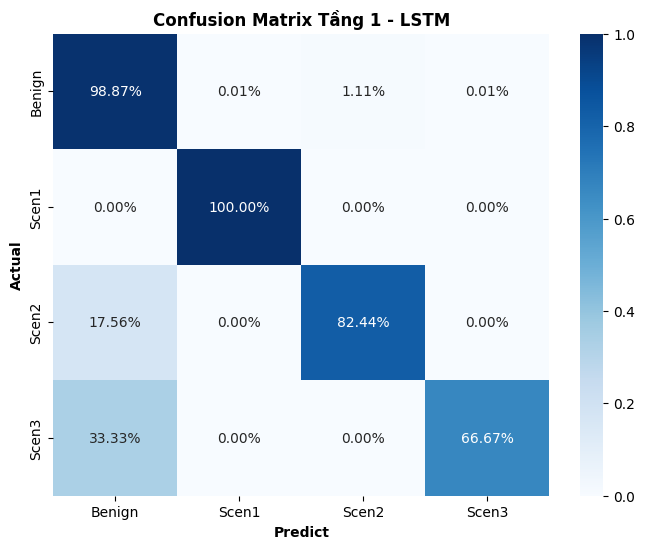


-> [MÀNG LỌC VỚT] Tầng 2 đã soi 89393 mẫu Benign và lôi cổ thêm được:
   + 394 mẫu Scen2 ẩn mình (Ngưỡng 0.5)!

🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)
              precision    recall  f1-score   support

      Benign     0.9999    0.9845    0.9921     90388
       Scen1     0.3333    1.0000    0.5000         5
       Scen2     0.0806    0.9237    0.1483       131
       Scen3     0.1667    0.6667    0.2667         3

    accuracy                         0.9844     90527
   macro avg     0.3951    0.8937    0.4768     90527
weighted avg     0.9985    0.9844    0.9909     90527



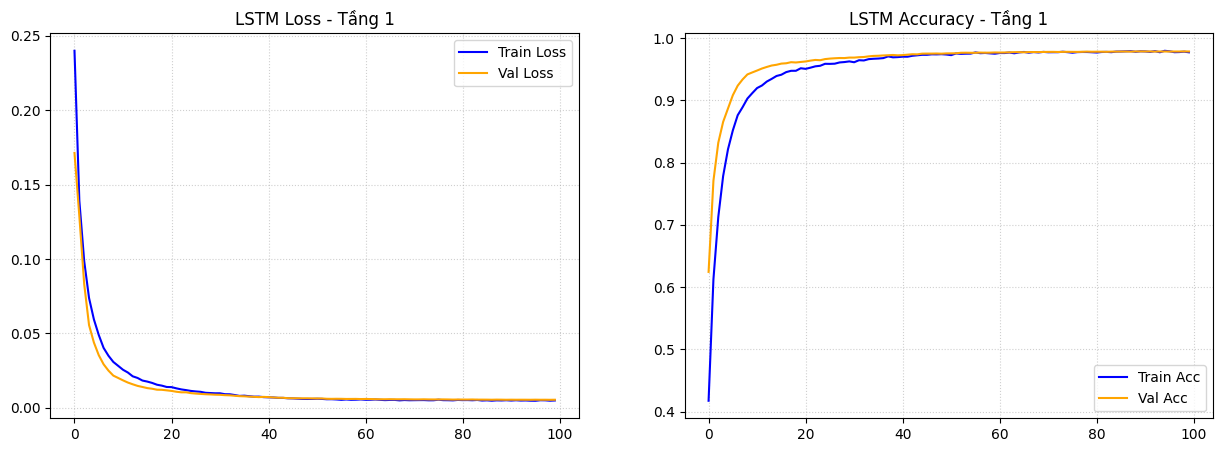

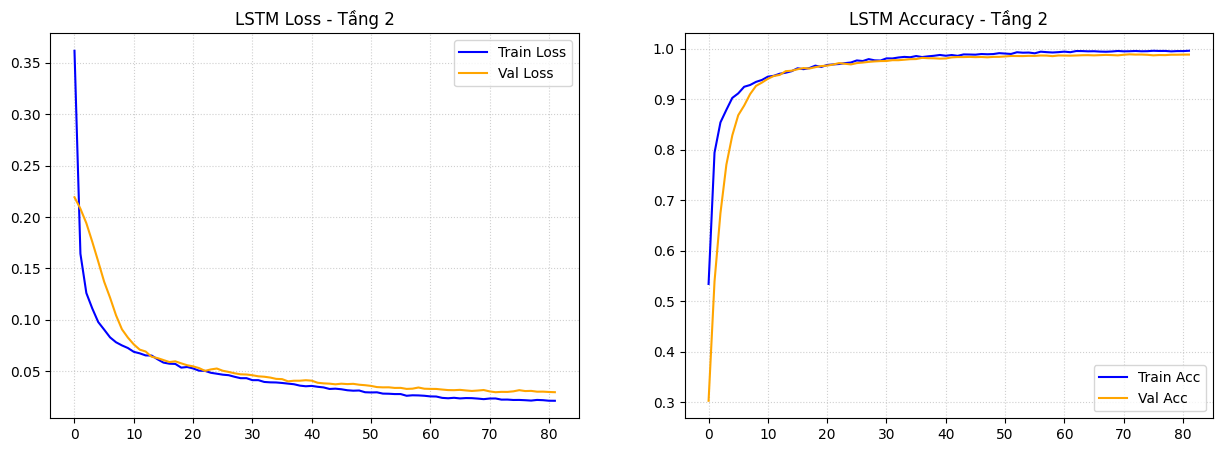

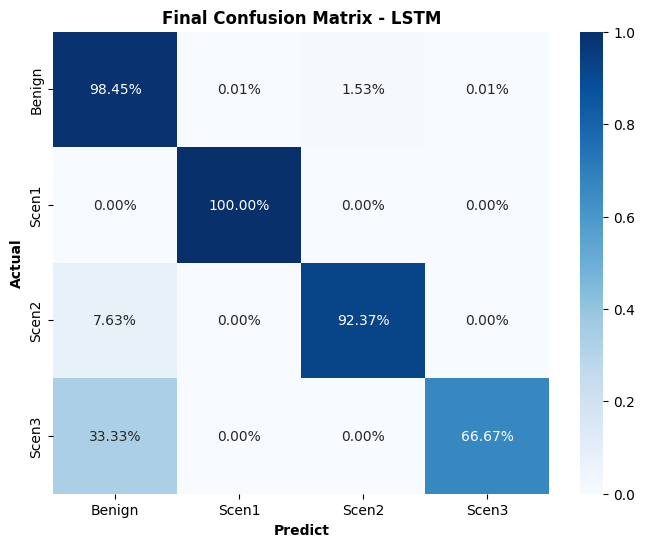

In [1]:
#LSTM Cân Bằng RUS+SMOTE (Tích hợp AUC & Vẽ biểu đồ 3 trục)
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm
import warnings
import time
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy, BinaryFocalCrossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os, random

# 🔒 HÀM CỐ ĐỊNH SEED BẮT BUỘC ĐỂ KẾT QUẢ KHÔNG NHẢY MÚA
# def set_all_seeds(seed=42):
#     os.environ['PYTHONHASHSEED'] = str(seed)
#     os.environ['TF_DETERMINISTIC_OPS'] = '1'
#     os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
#     random.seed(seed)
#     np.random.seed(seed)
#     tf.random.set_seed(seed)
#     tf.keras.backend.clear_session()
#     print(f"🔒 [HỆ THỐNG] Đã khóa chặt toàn bộ tính ngẫu nhiên với SEED = {seed}")

# set_all_seeds(42)
warnings.filterwarnings('ignore')

# ==============================================================================
# 1. LOAD DATA & TIỀN XỬ LÝ (GIỮ NGUYÊN NHƯ CỦA BẠN)
# ==============================================================================
print("\n[1/5] Đang đọc file Parquet và chia tập Train/Val/Test...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']

feature_cols = [col for col in df.columns if col not in (exclude_cols)]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))
    
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# XÓA CỘT ZERO VARIANCE
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

# ==============================================================================
# 3️⃣ PHÂN LOẠI (FREQUENCY SMOOTHING) & SCALE CHỌN LỌC
# ==============================================================================
print("\n[3/5] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...")

categorical_cols = ['pc', 'start_with', 'end_with', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

# 1. ÁP DỤNG FREQUENCY ENCODING (CÓ BƠM ĐÁY SMOOTHING)
for col in cat_cols_to_keep:
    # Lập từ điển đếm tỷ lệ % xuất hiện trên tập TRAIN
    freq_map_raw = df_train[col].value_counts(normalize=True).to_dict()
    # 🔴 BÍ KÍP CỦA BẠN: Ép đáy 1% (0.01) để chống rỗ ranh giới cho các giá trị cực hiếm
    freq_map = {k: max(v, 0.01) for k, v in freq_map_raw.items()}
    # Map tỷ lệ lên các tập. Nếu Test có giá trị lạ hoắc, gán = 0.01 (Mức đáy) thay vì 0
    df_train[col] = df_train[col].map(freq_map).fillna(0.01)
    df_val[col]   = df_val[col].map(freq_map).fillna(0.01)
    df_test[col]  = df_test[col].map(freq_map).fillna(0.01)

# 2. SCALE TOÀN BỘ DỮ LIỆU (NHƯNG BỎ CATEGORICAL RA)
# 🔴 BÍ KÍP CỦA BẠN: Giữ nguyên Categorical trong dải [0.01, 1.0], CHỈ Scale Numeric!
scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# Lúc này feature_cols vẫn giữ nguyên trật tự, chỉ là giá trị bên trong đã được tối ưu
print(f" -> Đã ép {len(cat_cols_to_keep)} cột Categorical thành Tần suất (Có Smoothing đáy 1%).")
print(f" -> Đã Scale chuẩn hóa {len(num_cols_to_scale)} cột Numeric.")
print(f" -> Tổng số đặc trưng (Features) đưa vào Tensor 3D: {len(feature_cols)} (Hoàn hảo!)")

# ==============================================================================
# 4️⃣ TẠO TENSOR 3D BẰNG SLIDING WINDOW 
# ==============================================================================
print("\n[2/5] Đang cuộn dữ liệu thành Tensor 3D cho BiLSTM...")

# def create_sliding_windows_3D(df_subset, window_size=5, step=1):
#     df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
#     X_list, y_list = [], []
#     for user, group in tqdm(df_subset.groupby('user'), leave=False):
#         if len(group) < window_size: continue
#         features, labels = group[feature_cols].values, group['insider'].values
        
#         # 🔴 BÍ KÍP Ở ĐÂY: Thêm 'step' vào vòng lặp range
#         for i in range(0, len(group) - window_size + 1, step):
#             X_list.append(features[i : i + window_size])
#             y_list.append(np.max(labels[i : i + window_size]))
#             #y_list.append((labels[i + window_size - 1]))
            
#     return np.array(X_list), np.array(y_list)

def create_sliding_windows_3D(df_subset, window_size=5, step=1, k=2):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: 
            continue
        
        features = group[feature_cols].values
        labels = group['insider'].values
        
        for i in range(0, len(group) - window_size + 1, step):
            window_x = features[i : i + window_size]
            window_y = labels[i : i + window_size]
            
            # Xử lý nhãn Đa lớp theo ngưỡng k
            vals, counts = np.unique(window_y, return_counts=True)
            y = 0 # Default: 0 (Normal)
            
            abnormal_mask = vals != 0
            if np.any(abnormal_mask):
                abnormal_vals = vals[abnormal_mask]
                abnormal_counts = counts[abnormal_mask]
                max_count_idx = np.argmax(abnormal_counts)
                
                if abnormal_counts[max_count_idx] >= k:
                    y = abnormal_vals[max_count_idx]
            
            X_list.append(window_x)
            y_list.append(y)
            
    return np.array(X_list), np.array(y_list)
    
WINDOW_SIZE = 5
# # 🔴 TẬP TRAIN: Ép nhảy 2 bước (hoặc 3) để giảm Overlap, chống học vẹt!
# X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE, step=1) 
# # 🔴 TẬP VAL & TEST: Vẫn giữ step=1 để khám nghiệm không bỏ sót bất kỳ giây phút nào!
# X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE, step=1)
# X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE, step=1)

X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE, step=1, k=2)
X_val, y_val     = create_sliding_windows_3D(df_val, WINDOW_SIZE, step=1, k=2)
X_test, y_test   = create_sliding_windows_3D(df_test, WINDOW_SIZE, step=1, k=2)

# ==============================================================================
# 🟢 PHẦN 1: MÔ HÌNH CHÍNH (MAIN MODEL BiLSTM - 4 LỚP)
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (RANDOM UNDERSAMPLER + SMOTE)")
print("="*75)

N_train, T, F = X_train.shape
X_train_flat = X_train.reshape(N_train, T * F)

rus = RandomUnderSampler(sampling_strategy={0: 20000}, random_state=42)
X_res_flat, y_res = rus.fit_resample(X_train_flat, y_train)

smote_main = SMOTE(sampling_strategy={1: 5000, 2: 5000, 3: 5000}, random_state=42, k_neighbors=2)
X_main_flat, y_main_bal = smote_main.fit_resample(X_res_flat, y_res)

X_train_main = X_main_flat.reshape(-1, T, F)
# ====================================================================
# 🔴 BÍ KÍP CẤP CỨU CỘT CATEGORICAL SAU KHI SMOTE
# ====================================================================
print("-> Đang nắn gân lại các cột Categorical bị SMOTE làm hỏng...")

# Lấy index của các cột không bị scale
cat_indices = [feature_cols.index(col) for col in cat_cols_to_keep]

# Ép kiểu (Làm tròn số thập phân về lại số nguyên chuẩn)
for idx in cat_indices:
    # Round (làm tròn gần nhất) và ép về float/int để tránh lỗi shape
    X_train_main[:, :, idx] = np.round(X_train_main[:, :, idx])

print("✅ Đã làm tròn xong các cột bảo vệ (role, dept, pc...)!")
# 🔴 BÍ KÍP: CHUYỂN NHÃN SANG ONE-HOT ĐỂ TÍNH ĐƯỢC AUC ĐA LỚP
y_main_bal_onehot = tf.keras.utils.to_categorical(y_main_bal, num_classes=4)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=4)

start_time_t1 = time.time()
model_main = Sequential([
    LSTM(128, return_sequences=True, input_shape=(T, F)), Dropout(0.3),
    LSTM(64, return_sequences=False), Dropout(0.3),
    Dense(64, activation='relu'), BatchNormalization(), Dropout(0.2),
    #Dense(32, activation='relu'), BatchNormalization(), Dropout(0.2),
    Dense(4, activation='softmax')
])

focal_loss_t1 = CategoricalFocalCrossentropy(
    gamma=2.0, 
    #alpha=[0.05, 0.15, 0.35, 0.25] # (Tùy chọn) Có thể bật dòng này nếu muốn ép thêm tạ
)

model_main.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), 
    loss=focal_loss_t1, 
    metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
)

es_main = EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True)
rlr_main = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
# es_main = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
# rlr_main = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=1e-6, verbose=1)

history_main = model_main.fit(
    X_train_main, y_main_bal_onehot, 
    validation_data=(X_val, y_val_onehot),
    epochs=100, batch_size=256, callbacks=[es_main, rlr_main], verbose=1
)
train_time_t1 = time.time() - start_time_t1

# ==============================================================================
# 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA (NHỊ PHÂN: BENIGN vs SCEN 2)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (BINARY: BENIGN vs SCEN 2)")
print("="*75)

# 1. Lọc tập Train & Val (Chỉ lấy Benign=0 và Scen2=2 từ tập Train cân bằng của T1)
mask_train = (y_main_bal == 0) | (y_main_bal == 2)
X_train_expert_raw = X_train_main[mask_train]
y_train_expert_raw = y_main_bal[mask_train]
mask_val = (y_val == 0) | (y_val == 2)
X_val_expert = X_val[mask_val]
y_val_expert_raw = y_val[mask_val]
# 2. Map nhãn về Nhị phân (0: Benign, 1: Scen2)
y_train_expert_bin = np.where(y_train_expert_raw == 2, 1, 0)
y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)
# ====================================================================
# 🔴 3. BÍ KÍP ÉP TỶ LỆ 1:1 CHO TẬP TRAIN TẦNG 2
# ====================================================================
print("-> Đang xén bớt Benign để ép tỷ lệ 1:1 cho Tầng 2...")
# Lấy ra index của từng nhóm
idx_benign = np.where(y_train_expert_bin == 0)[0]
idx_scen2 = np.where(y_train_expert_bin == 1)[0]
# Đếm số lượng của Scen 2 (Nhóm thiểu số)
num_scen2 = len(idx_scen2)
# Bốc ngẫu nhiên Benign sao cho số lượng vừa bằng đúng Scen 2
np.random.seed(42) # Khóa Seed cho chắc cú
idx_benign_downsampled = np.random.choice(idx_benign, size=num_scen2, replace=False)
# Gom 2 nhóm index lại và xáo trộn lên (Shuffle)
idx_balanced = np.concatenate([idx_benign_downsampled, idx_scen2])
np.random.shuffle(idx_balanced)
# Tạo ra tập Train Tầng 2 MỚI, CHUẨN, VÀ CÂN BẰNG 1:1
X_train_expert = X_train_expert_raw[idx_balanced]
y_train_expert = y_train_expert_bin[idx_balanced]
print(f"✅ Đã cân bằng xong! Phân bổ Train Tầng 2: {dict(zip(*np.unique(y_train_expert, return_counts=True)))}")

start_time_t2 = time.time()
model_expert = Sequential([
    LSTM(64, return_sequences=True, input_shape=(T, F)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    # 🔴 Đã lùi về 1 Nơ-ron với hàm Sigmoid (Chuyên trị Nhị phân)
    Dense(1, activation='sigmoid') 
])
focal_loss_binary = BinaryFocalCrossentropy(
    gamma=2.0, 
    #apply_class_balancing=True,
)
model_expert.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss=focal_loss_binary, 
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy'] # Bỏ multi_label đi
)

es_expert = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
print("\n🚀 BẮT ĐẦU TRAINING TẦNG 2 (SALVAGE NET)...")
history_expert = model_expert.fit(
    X_train_expert, y_train_expert, 
    validation_data=(X_val_expert, y_val_expert),
    epochs=150, batch_size=256, callbacks=[es_expert, rlr_expert], verbose=1
)
train_time_t2 = time.time() - start_time_t2
print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")
############################################################################################
# ==============================================================================
# 🔴 PHẦN 3: ĐÁNH GIÁ LIÊN HOÀN (SALVAGE NET S1, S2 & S3)
# ==============================================================================
print("\n[4/4] Khám nghiệm tập Test qua Màng Lọc Vớt Toàn Diện...")
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
probs_main = model_main.predict(X_test, verbose=0)

#preds_main = np.argmax(probs_main, axis=1)

THRESHOLDS_T1 = {
    1: 0.90,  # Lớp 1 phải chắc chắn >= 80% mới được phán
    2: 0.60,  # Lớp 2 phải chắc chắn >= 85%
    3: 0.70   # Lớp 3 hiếm hơn, có thể để ngưỡng thấp hơn một chút
}

preds_main = np.zeros(len(probs_main), dtype=int) # Mặc định ban đầu mọi thứ là Benign (0)

for i in range(len(probs_main)):
    p_s1 = probs_main[i, 1]
    p_s2 = probs_main[i, 2]
    p_s3 = probs_main[i, 3]
    
    candidates = []
    # Kiểm tra xem có kịch bản nào vượt qua bài kiểm tra "độ tự tin" không
    if p_s1 >= THRESHOLDS_T1[1]: candidates.append((1, p_s1))
    if p_s2 >= THRESHOLDS_T1[2]: candidates.append((2, p_s2))
    if p_s3 >= THRESHOLDS_T1[3]: candidates.append((3, p_s3))
    
    if candidates:
        # Nếu có từ 1 lớp trở lên vượt ngưỡng, chọn lớp có xác suất cao nhất trong số đó
        best_class = max(candidates, key=lambda item: item[1])[0]
        preds_main[i] = best_class
    # Nếu không lớp nào vượt ngưỡng, mẫu đó sẽ tự động giữ nguyên là 0 (Benign)

print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)")
print("="*50)
print(classification_report(y_test, preds_main, target_names=classes_names, digits=4, zero_division=0))

cm_final = confusion_matrix(y_test, preds_main)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix Tầng 1 - LSTM', fontweight='bold')
plt.show()

# --- MÀNG LỌC VỚT TẦNG 2 CHO SCEN 2 & SCEN 3 ---
final_preds = preds_main.copy()
review_idx = np.where(preds_main == 0)[0] # Trích xuất nhóm bị phán Benign

if len(review_idx) > 0:
    # probs_expert lúc này là mảng 2D shape (N, 1) chứa tỷ lệ % là Scen 2
    probs_expert = model_expert.predict(X_test[review_idx], verbose=0)
    # Ép phẳng về mảng 1D (N,) cho dễ tính toán
    probs_scen2 = probs_expert.flatten()
    # 🔴 ĐẶT NGƯỠNG VỚT CHO SCEN 2 (Tùy chỉnh 0.15 - 0.3)
    THRESHOLD_SCEN2 = 0.50
    # Tìm những đứa vượt ngưỡng
    is_scen2 = probs_scen2 >= THRESHOLD_SCEN2
    # Cập nhật mảng kết quả
    new_preds = np.zeros(len(review_idx), dtype=int)
    new_preds[is_scen2] = 2 
    # Đè lên mảng final_preds gốc
    mask_update = new_preds == 2
    indices_to_update = review_idx[mask_update]
    final_preds[indices_to_update] = 2
    print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 đã soi {len(review_idx)} mẫu Benign và lôi cổ thêm được:")
    print(f"   + {np.sum(new_preds == 2)} mẫu Scen2 ẩn mình (Ngưỡng {THRESHOLD_SCEN2})!")

# ==============================================================================
# XUẤT BÁO CÁO CUỐI CÙNG & BIỂU ĐỒ (NÂNG CẤP VỚI AUC)
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 1
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))

axes1[0].plot(history_main.history['loss'], label='Train Loss', color='blue')
axes1[0].plot(history_main.history['val_loss'], label='Val Loss', color='orange')
axes1[0].set_title('LSTM Loss - Tầng 1')
axes1[0].legend(); axes1[0].grid(True, linestyle=':', alpha=0.6)

axes1[1].plot(history_main.history['accuracy'], label='Train Acc', color='blue')
axes1[1].plot(history_main.history['val_accuracy'], label='Val Acc', color='orange')
axes1[1].set_title('LSTM Accuracy - Tầng 1')
axes1[1].legend(); axes1[1].grid(True, linestyle=':', alpha=0.6)

plt.show()

# 🔴 VẼ 3 TRỤC: LOSS, ACCURACY VÀ AUC CHO TẦNG 2
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))

axes2[0].plot(history_expert.history['loss'], label='Train Loss', color='blue')
axes2[0].plot(history_expert.history['val_loss'], label='Val Loss', color='orange')
axes2[0].set_title('LSTM Loss - Tầng 2')
axes2[0].legend(); axes2[0].grid(True, linestyle=':', alpha=0.6)

axes2[1].plot(history_expert.history['accuracy'], label='Train Acc', color='blue')
axes2[1].plot(history_expert.history['val_accuracy'], label='Val Acc', color='orange')
axes2[1].set_title('LSTM Accuracy - Tầng 2')
axes2[1].legend(); axes2[1].grid(True, linestyle=':', alpha=0.6)

plt.show()

# MA TRẬN NHẦM LẪN
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Final Confusion Matrix - LSTM', fontweight='bold')
plt.show()

In [ ]:
import shap

# 1. Chuẩn bị background (Dùng tập train đã xử lý)
background = X_train_main[np.random.choice(X_train_main.shape[0], 500, replace=False)]

# 2. Khởi tạo Explainer
explainer = shap.GradientExplainer(model_main, background)

# 3. Tính toán SHAP (giảm xuống 200-500 mẫu để tránh treo máy, 1000 hơi nặng)
test_samples = X_test[np.random.choice(X_test.shape[0], 2000, replace=False)]
shap_values = explainer.shap_values(test_samples)

# Kiểm tra xem shap_values là list hay array
# Với multiclass, thường là list: [array_class0, array_class1, ...]
print(f"Kiểm tra kiểu dữ liệu SHAP: {type(shap_values)}")

for i, class_name in enumerate(classes_names):
    print(f"\n--- Đang phân tích lớp: {class_name} ---")
    
    # Lấy dữ liệu SHAP cho lớp thứ i
    # Nếu là list thì lấy shap_values[i], nếu là array thì lấy shap_values[:,:,:,i]
    if isinstance(shap_values, list):
        current_shap = shap_values[i]
    else:
        current_shap = shap_values[..., i]

    # Đảm bảo current_shap là (N, Window_Size, Features)
    # Tính trung bình trị tuyệt đối trên toàn bộ mẫu và toàn bộ 5 bước thời gian (Sliding Window)
    # Chúng ta ép về mảng 2D (N*Window_Size, Features) rồi mới tính mean để an toàn
    flat_shap = current_shap.reshape(-1, current_shap.shape[-1])
    val = np.abs(flat_shap).mean(axis=0)
    
    # Tạo DataFrame
    feature_importance = pd.DataFrame({
        'col': feature_cols,
        'importance': val
    })
    
    # Sắp xếp và lấy Top 15
    feature_importance = feature_importance.sort_values(by='importance', ascending=False).head(20)
    
    # Kiểm tra số lượng thực tế in ra
    print(f"Số lượng feature tìm thấy: {len(feature_importance)}")
    
    # Vẽ biểu đồ
    plt.figure(figsize=(10, 8))
    sns.barplot(x='importance', y='col', data=feature_importance, palette='magma')
    plt.title(f'Top 15 đặc trưng ảnh hưởng nhất đến lớp: {class_name}')
    plt.xlabel('SHAP Value (Càng cao càng quan trọng)')
    plt.ylabel('Tên đặc trưng')
    plt.tight_layout()
    plt.show()

In [ ]:
# ==============================================================================
# HỆ THỐNG PHÁT HIỆN TẤN CÔNG: SHALLOW WGAN-GP + LSTM CASCADE
# ==============================================================================
import pandas as pd
import numpy as np
import gc
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
import warnings
import time
import tensorflow as tf
from tensorflow.keras.losses import CategoricalFocalCrossentropy, BinaryFocalCrossentropy
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization, Input, Reshape, Flatten, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os, random

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. LOAD DATA & TIỀN XỬ LÝ
# ==============================================================================
print("\n[1/6] Đang đọc file Parquet và chia tập Train/Val/Test...")
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week']
feature_cols = [col for col in df.columns if col not in exclude_cols]

def split_user_time_multiclass(df, label_col='insider'):
    df = df.sort_values(by='starttime').reset_index(drop=True)
    test_idx = int(len(df) * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    
    val_idx = int(len(df_past) * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    
    return (df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True),
            df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True))
    
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# XÓA CỘT ZERO VARIANCE
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')
feature_cols = [c for c in feature_cols if c not in dead_cols]

# ==============================================================================
# 2. PHÂN LOẠI (FREQUENCY SMOOTHING) & SCALE CHỌN LỌC
# ==============================================================================
print("\n[2/6] Đang xử lý Categorical (Frequency Smoothing) và Scale Numeric...")

categorical_cols = ['pc', 'start_with', 'end_with', 'role', 'b_unit', 'f_unit', 'dept', 'team', 'ITAdmin']
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

for col in cat_cols_to_keep:
    freq_map_raw = df_train[col].value_counts(normalize=True).to_dict()
    freq_map = {k: max(v, 0.01) for k, v in freq_map_raw.items()}
    df_train[col] = df_train[col].map(freq_map).fillna(0.01)
    df_val[col]   = df_val[col].map(freq_map).fillna(0.01)
    df_test[col]  = df_test[col].map(freq_map).fillna(0.01)

scaler = StandardScaler()
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 3. TẠO TENSOR 3D BẰNG SLIDING WINDOW 
# ==============================================================================
print("\n[3/6] Đang cuộn dữ liệu thành Tensor 3D...")

def create_sliding_windows_3D(df_subset, window_size=5, step=1):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        if len(group) < window_size: continue
        features, labels = group[feature_cols].values, group['insider'].values
        for i in range(0, len(group) - window_size + 1, step):
            X_list.append(features[i : i + window_size])
            y_list.append(np.max(labels[i : i + window_size]))
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE, step=1) 
X_val, y_val = create_sliding_windows_3D(df_val, WINDOW_SIZE, step=1)
X_test, y_test = create_sliding_windows_3D(df_test, WINDOW_SIZE, step=1)

N_train, T, F = X_train.shape
cat_indices = [feature_cols.index(col) for col in cat_cols_to_keep]

# ==============================================================================
# 4. ÁP DỤNG SHALLOW WGAN-GP THAY CHO SMOTE
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẠO DỮ LIỆU ẢO BẰNG WGAN-GP (SHALLOW ARCHITECTURE)")
print("="*75)

class WGANGP(tf.keras.Model):
    def __init__(self, critic, generator, latent_dim, critic_steps=5, gp_weight=10.0):
        super(WGANGP, self).__init__()
        self.critic = critic
        self.generator = generator
        self.latent_dim = latent_dim
        self.critic_steps = critic_steps
        self.gp_weight = gp_weight

    def compile(self, c_optimizer, g_optimizer):
        super(WGANGP, self).compile()
        self.c_optimizer = c_optimizer
        self.g_optimizer = g_optimizer

    @tf.function
    def train_step(self, real_data):
        batch_size = tf.shape(real_data)[0]
        
        # 1. Train Critic
        for _ in range(self.critic_steps):
            random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
            with tf.GradientTape() as tape:
                fake_data = self.generator(random_latent_vectors, training=True)
                fake_logits = self.critic(fake_data, training=True)
                real_logits = self.critic(real_data, training=True)
                c_loss = tf.reduce_mean(fake_logits) - tf.reduce_mean(real_logits)
                
                # Gradient Penalty
                alpha = tf.random.uniform(shape=(batch_size, 1, 1))
                interpolated = real_data + alpha * (fake_data - real_data)
                with tf.GradientTape() as gp_tape:
                    gp_tape.watch(interpolated)
                    pred = self.critic(interpolated, training=True)
                grads = gp_tape.gradient(pred, [interpolated])[0]
                grads_flat = tf.reshape(grads, [batch_size, -1])
                norm = tf.sqrt(tf.reduce_sum(tf.square(grads_flat), axis=1) + 1e-12)
                gp = tf.reduce_mean((norm - 1.0) ** 2)
                
                total_c_loss = c_loss + self.gp_weight * gp
            c_gradient = tape.gradient(total_c_loss, self.critic.trainable_variables)
            self.c_optimizer.apply_gradients(zip(c_gradient, self.critic.trainable_variables))

        # 2. Train Generator
        random_latent_vectors = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            fake_data = self.generator(random_latent_vectors, training=True)
            fake_logits = self.critic(fake_data, training=True)
            g_loss = -tf.reduce_mean(fake_logits)
        g_gradient = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_optimizer.apply_gradients(zip(g_gradient, self.generator.trainable_variables))
        return {"c_loss": total_c_loss, "g_loss": g_loss}

def build_wgan_generator(latent_dim, T, F):
    inputs = Input(shape=(latent_dim,))
    x = Dense(128)(inputs)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)
    x = Dense(256)(x)
    x = LeakyReLU(alpha=0.2)(x)
    x = BatchNormalization()(x)
    x = Dense(T * F, activation='linear')(x)
    outputs = Reshape((T, F))(x)
    return Model(inputs, outputs)

def build_wgan_critic(T, F):
    inputs = Input(shape=(T, F))
    x = Flatten()(inputs)
    x = Dense(256)(x)
    x = LeakyReLU(alpha=0.2)(x) # KHÔNG DÙNG BatchNormalization TRONG CRITIC
    x = Dense(128)(x)
    x = LeakyReLU(alpha=0.2)(x)
    outputs = Dense(1)(x)
    return Model(inputs, outputs)

# --- THIẾT LẬP CÂN BẰNG ---
TARGET_BENIGN = 15000
TARGET_MINORITY = 3000 # Số lượng mẫu an toàn, không quá phình to để tránh Overlap
LATENT_DIM = 64
EPOCHS_GAN = 150 
BATCH_SIZE_GAN = 64

X_bal_list, y_bal_list = [], []

# 1. Downsample Benign
X_b = X_train[y_train == 0]
idx_b = np.random.choice(len(X_b), min(len(X_b), TARGET_BENIGN), replace=False)
X_bal_list.append(X_b[idx_b])
y_bal_list.append(np.zeros(len(idx_b)))

# 2. Train WGAN & Sinh dữ liệu cho từng lớp thiểu số
for cls in [1, 2, 3]:
    X_cls = X_train[y_train == cls]
    real_count = len(X_cls)
    num_to_generate = max(0, TARGET_MINORITY - real_count)
    
    # Thêm dữ liệu gốc vào danh sách
    X_bal_list.append(X_cls)
    y_bal_list.append(np.full(real_count, cls))
    
    if num_to_generate > 0:
        print(f"-> Đang huấn luyện WGAN-GP cho Lớp {cls} (Tạo {num_to_generate} mẫu)...")
        gen = build_wgan_generator(LATENT_DIM, T, F)
        crit = build_wgan_critic(T, F)
        
        wgan = WGANGP(critic=crit, generator=gen, latent_dim=LATENT_DIM)
        wgan.compile(
            c_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9),
            g_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)
        )
        
        # Train WGAN
        wgan.fit(X_cls, batch_size=BATCH_SIZE_GAN, epochs=EPOCHS_GAN, verbose=0)
        
        # Sinh dữ liệu
        random_latent_vectors = tf.random.normal(shape=(num_to_generate, LATENT_DIM))
        X_fake = gen(random_latent_vectors, training=False).numpy()
        
        # Ép kiểu Categorical cho dữ liệu sinh ra
        for idx in cat_indices:
            X_fake[:, :, idx] = np.round(X_fake[:, :, idx])
            
        X_bal_list.append(X_fake)
        y_bal_list.append(np.full(num_to_generate, cls))
        print(f"   [Hoàn tất] Sinh thành công Lớp {cls}.")

# Gom tất cả lại và xáo trộn
X_train_main = np.vstack(X_bal_list)
y_train_bal = np.concatenate(y_bal_list)

shuffle_idx = np.random.permutation(len(y_train_bal))
X_train_main = X_train_main[shuffle_idx]
y_train_bal = y_train_bal[shuffle_idx]

print(f"\n✅ Hoàn tất cân bằng WGAN-GP! Phân bổ tập Train mới: {dict(zip(*np.unique(y_train_bal, return_counts=True)))}")

# ==============================================================================
# 5. TẦNG 1: HUẤN LUYỆN MAIN MODEL (LSTM)
# ==============================================================================
print("\n" + "="*75)
print("🟢 TẦNG 1: HUẤN LUYỆN MAIN MODEL (LSTM - ĐA LỚP)")
print("="*75)

y_main_bal_onehot = tf.keras.utils.to_categorical(y_train_bal, num_classes=4)
y_val_onehot = tf.keras.utils.to_categorical(y_val, num_classes=4)

start_time_t1 = time.time()
model_main = Sequential([
    LSTM(128, return_sequences=True, input_shape=(T, F)), Dropout(0.3),
    LSTM(64, return_sequences=False), Dropout(0.3),
    Dense(64, activation='relu'), BatchNormalization(), Dropout(0.2),
    Dense(4, activation='softmax')
])

model_main.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Tăng LR để học nhanh hơn
    loss='categorical_crossentropy', 
    metrics=[tf.keras.metrics.AUC(multi_label=True, num_labels=4, name='auc'), 'accuracy']
)

es_main = EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)
rlr_main = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_main = model_main.fit(
    X_train_main, y_main_bal_onehot, 
    validation_data=(X_val, y_val_onehot),
    epochs=100, batch_size=256, callbacks=[es_main, rlr_main], verbose=1
)
train_time_t1 = time.time() - start_time_t1

# ==============================================================================
# 6. TẦNG 2: MÔ HÌNH CHUYÊN GIA (NHỊ PHÂN: BENIGN vs SCEN 2)
# ==============================================================================
print("\n" + "="*75)
print("🔵 TẦNG 2: HUẤN LUYỆN SALVAGE NET (BINARY: BENIGN vs SCEN 2)")
print("="*75)

mask_train = (y_train_bal == 0) | (y_train_bal == 2)
X_train_expert_raw = X_train_main[mask_train]
y_train_expert_raw = y_train_bal[mask_train]

mask_val = (y_val == 0) | (y_val == 2)
X_val_expert = X_val[mask_val]
y_val_expert_raw = y_val[mask_val]

y_train_expert_bin = np.where(y_train_expert_raw == 2, 1, 0)
y_val_expert = np.where(y_val_expert_raw == 2, 1, 0)

# Ép tỷ lệ 1:1 cho Tầng 2
idx_benign = np.where(y_train_expert_bin == 0)[0]
idx_scen2 = np.where(y_train_expert_bin == 1)[0]
np.random.seed(42)
idx_benign_downsampled = np.random.choice(idx_benign, size=len(idx_scen2), replace=False)
idx_balanced = np.concatenate([idx_benign_downsampled, idx_scen2])
np.random.shuffle(idx_balanced)

X_train_expert = X_train_expert_raw[idx_balanced]
y_train_expert = y_train_expert_bin[idx_balanced]

start_time_t2 = time.time()
model_expert = Sequential([
    LSTM(64, return_sequences=True, input_shape=(T, F)), Dropout(0.2),
    LSTM(32, return_sequences=False), Dropout(0.2),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)), BatchNormalization(),
    Dense(1, activation='sigmoid') 
])

model_expert.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    loss='binary_crossentropy', 
    metrics=[tf.keras.metrics.AUC(name='auc'), 'accuracy']
)

es_expert = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rlr_expert = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_expert = model_expert.fit(
    X_train_expert, y_train_expert, 
    validation_data=(X_val_expert, y_val_expert),
    epochs=150, batch_size=256, callbacks=[es_expert, rlr_expert], verbose=1
)
train_time_t2 = time.time() - start_time_t2
print(f"🚀 TỔNG THỜI GIAN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")

# ==============================================================================
# 7. ĐÁNH GIÁ LIÊN HOÀN (SALVAGE NET CASCADE)
# ==============================================================================
print("\n[4/4] Khám nghiệm tập Test qua Màng Lọc Vớt Toàn Diện...")
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']
probs_main = model_main.predict(X_test, verbose=0)
preds_main = np.argmax(probs_main, axis=1)

print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)")
print("="*50)
print(classification_report(y_test, preds_main, target_names=classes_names, digits=4, zero_division=0))

cm_final = confusion_matrix(y_test, preds_main)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Confusion Matrix Tầng 1 - LSTM', fontweight='bold')
plt.show()

final_preds = preds_main.copy()
review_idx = np.where(preds_main == 0)[0] 

if len(review_idx) > 0:
    probs_expert = model_expert.predict(X_test[review_idx], verbose=0).flatten()
    THRESHOLD_SCEN2 = 0.25
    is_scen2 = probs_expert >= THRESHOLD_SCEN2
    
    new_preds = np.zeros(len(review_idx), dtype=int)
    new_preds[is_scen2] = 2 
    
    mask_update = new_preds == 2
    indices_to_update = review_idx[mask_update]
    final_preds[indices_to_update] = 2
    print(f"\n-> [MÀNG LỌC VỚT] Tầng 2 soi {len(review_idx)} mẫu Benign và lôi cổ thêm được: {np.sum(new_preds == 2)} mẫu Scen2!")

# ==============================================================================
# XUẤT BÁO CÁO CUỐI CÙNG & BIỂU ĐỒ
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))
axes1[0].plot(history_main.history['loss'], label='Train Loss', color='blue')
axes1[0].plot(history_main.history['val_loss'], label='Val Loss', color='orange')
axes1[0].set_title('LSTM Loss - Tầng 1'); axes1[0].legend(); axes1[0].grid(True, linestyle=':', alpha=0.6)
axes1[1].plot(history_main.history['accuracy'], label='Train Acc', color='blue')
axes1[1].plot(history_main.history['val_accuracy'], label='Val Acc', color='orange')
axes1[1].set_title('LSTM Accuracy - Tầng 1'); axes1[1].legend(); axes1[1].grid(True, linestyle=':', alpha=0.6)
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5))
axes2[0].plot(history_expert.history['loss'], label='Train Loss', color='blue')
axes2[0].plot(history_expert.history['val_loss'], label='Val Loss', color='orange')
axes2[0].set_title('LSTM Loss - Tầng 2'); axes2[0].legend(); axes2[0].grid(True, linestyle=':', alpha=0.6)
axes2[1].plot(history_expert.history['accuracy'], label='Train Acc', color='blue')
axes2[1].plot(history_expert.history['val_accuracy'], label='Val Acc', color='orange')
axes2[1].set_title('LSTM Accuracy - Tầng 2'); axes2[1].legend(); axes2[1].grid(True, linestyle=':', alpha=0.6)
plt.show()

cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]
plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold'); plt.ylabel('Actual', fontweight='bold')
plt.title('Final Confusion Matrix - WGAN-GP + LSTM Cascade', fontweight='bold')
plt.show()

In [ ]:
##########################################
# LSTM RUS+VAE
##########################################
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import gc
import warnings
import time
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ==============================================================================
# 1️⃣ ĐỌC DỮ LIỆU & LỌC CỘT
# ==============================================================================
file_path = '/kaggle/input/datasets/phanthanhhoang/cert-r42-session/session_r4.2.parquet'
df = pd.read_parquet(file_path)
df['insider'] = df['insider'].astype(int)

# Sort chuẩn theo User và Thời gian
df = df.sort_values(by=['user', 'starttime']).reset_index(drop=True)

# Xác định danh sách feature (Bỏ qua các cột định danh)
exclude_cols = ['insider', 'starttime', 'endtime', 'sessionid', 'user', 'day', 'week',]

# drop_cols_leakage = [
    # leakf
    # 'http_n_leakf',
    # 'http_leakf_mean_url_len',
    # 'http_leakf_mean_url_depth',
    # 'http_leakf_mean_http_c_len',
    # 'http_leakf_mean_http_c_nwords',

#     # hackf
#     'http_n_hackf',
#     'http_hackf_mean_url_len',
#     'http_hackf_mean_url_depth',
#     'http_hackf_mean_http_c_len',
#     'http_hackf_mean_http_c_nwords',
# ]
# drop_cols_suspect = [
#     # phof (gần như chỉ class 2)
#     'file_n_phof',
#     'file_phof_mean_file_len',
#     'file_phof_mean_file_nwords',
#     'file_phof_n-disk0',
#     'file_phof_n-disk1',
#     'file_phof_n-disk2',

#     # cloudf (bias class 0 & 2)
#     'http_n_cloudf',
#     'http_cloudf_mean_url_len',
#     'http_cloudf_mean_url_depth',
#     'http_cloudf_mean_http_c_len',
#     'http_cloudf_mean_http_c_nwords',
# ]
# drop_cols_optional = [
#     'file_compf_n-disk1',
#     'file_compf_n-disk2',
#     'file_txtf_n-disk1',
#     'file_txtf_n-disk2',
#     'file_exef_n-disk1',
#     'file_exef_n-disk2',
# ]
feature_cols = [col for col in df.columns if col not in exclude_cols]

#feature_cols = [col for col in df.columns if col not in exclude_cols]

# ==============================================================================
# 2. TIME + USER SPLIT 
# ==============================================================================
def split_user_time_multiclass(df, label_col='insider'):
    print("\n SPLIT USER + TIME")
    # ------------------------------------------------------------------
    # 1. SORT TIME
    # ------------------------------------------------------------------
    df = df.sort_values(by='starttime').reset_index(drop=True)
    n = len(df)
    test_idx = int(n * 0.80)
    df_past = df.iloc[:test_idx].copy()
    df_future = df.iloc[test_idx:].copy()
    print(f"  -> Past: {len(df_past):,} | Future (Test): {len(df_future):,}")
    # ------------------------------------------------------------------
    # 2. LOẠI INSIDER TRONG FUTURE
    # ------------------------------------------------------------------
    known_insiders = set(df_past[df_past[label_col] != 0]['user'])
    df_test = df_future[~df_future['user'].isin(known_insiders)].copy()
    print(f"  -> Loại {len(known_insiders)} insider đã xuất hiện trong train khỏi TEST")
    # ------------------------------------------------------------------
    # 3. SPLIT TRAIN / VAL (TRONG PAST)
    # ------------------------------------------------------------------
    n_past = len(df_past)
    val_idx = int(n_past * 0.80)
    df_train = df_past.iloc[:val_idx].copy()
    df_val   = df_past.iloc[val_idx:].copy()
    # ------------------------------------------------------------------
    # 4. SORT LẠI THEO USER + TIME
    # ------------------------------------------------------------------
    df_train = df_train.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_val   = df_val.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    df_test  = df_test.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    # ------------------------------------------------------------------
    # 5. REPORT
    # ------------------------------------------------------------------
    print("\n📊 DATA REPORT")
    print("-" * 50)
    print(f"TRAIN: {len(df_train):,} samples | {df_train['user'].nunique()} users")
    print(df_train[label_col].value_counts())
    print(f"\nVAL: {len(df_val):,} samples | {df_val['user'].nunique()} users")
    print(df_val[label_col].value_counts())
    print(f"\nTEST: {len(df_test):,} samples | {df_test['user'].nunique()} users")
    print(df_test[label_col].value_counts())
    print("-" * 50)
    return df_train, df_val, df_test
df_train, df_val, df_test = split_user_time_multiclass(df, label_col='insider')

# ==============================================================================
# 2️⃣ XÓA CỘT ZERO VARIANCE (DỌN RÁC)
# ==============================================================================
print("\n Đang dọn dẹp các cột Zero Variance...")

# Tìm các cột không thay đổi giá trị trên tập Train
dead_cols = [c for c in feature_cols if df_train[c].nunique() <= 1]
print(f" -> Đã tìm thấy {len(dead_cols)} cột variance = 0.")

for d in [df_train, df_val, df_test]:
    d.drop(columns=dead_cols, inplace=True, errors='ignore')

# Cập nhật lại danh sách feature hợp lệ (Vẫn giữ đúng thứ tự cột ban đầu)
feature_cols = [c for c in feature_cols if c not in dead_cols]

# ==============================================================================
# 3️⃣ PHÂN LOẠI & SCALING CÓ CHỌN LỌC
# ==============================================================================
print("\nĐang phân loại và Scale các cột Numeric...")

categorical_cols = [
    'pc', 'start_with', 'end_with', 'ses_start', 'ses_end',
    'role', 'f_unit', 'dept', 'team', 'ITAdmin'
]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')
        df[col] = df[col].cat.codes
        
# Đảm bảo các cột đang tồn tại trong data
cat_cols_to_keep = [c for c in feature_cols if c in categorical_cols]

# Các cột còn lại sẽ Scale
num_cols_to_scale = [c for c in feature_cols if c not in cat_cols_to_keep]

print(f" -> {len(cat_cols_to_keep)} cột Categorical.")
print(f" -> {len(num_cols_to_scale)} cột Numeric.")

scaler = StandardScaler()

# Chỉ Scale đúng nhóm num_cols_to_scale
df_train[num_cols_to_scale] = scaler.fit_transform(df_train[num_cols_to_scale])
df_val[num_cols_to_scale]   = scaler.transform(df_val[num_cols_to_scale])
df_test[num_cols_to_scale]  = scaler.transform(df_test[num_cols_to_scale])

# ==============================================================================
# 4️⃣ TẠO MẢNG SLIDING WINDOW
# ==============================================================================
def create_sliding_windows_3D(df_subset, window_size=5):
    df_subset = df_subset.sort_values(by=['user', 'starttime']).reset_index(drop=True)
    X_list, y_list = [], []
    
    for user, group in tqdm(df_subset.groupby('user'), leave=False):
        group_len = len(group)
        if group_len < window_size: continue
            
        features = group[feature_cols].values
        labels   = group['insider'].values

        for i in range(group_len - window_size + 1):
            window_features = features[i : i + window_size] 
            window_label = np.max(labels[i : i + window_size]) # 🔴 ĐÃ QUAY VỀ MAX LABEL
            #window_label = labels[i + window_size - 1]
            X_list.append(window_features)
            y_list.append(window_label)
            
    return np.array(X_list), np.array(y_list)

WINDOW_SIZE = 5
X_train, y_train = create_sliding_windows_3D(df_train, WINDOW_SIZE)
X_val, y_val     = create_sliding_windows_3D(df_val, WINDOW_SIZE)
X_test, y_test   = create_sliding_windows_3D(df_test, WINDOW_SIZE)

N_train, T, F = X_train.shape

# ==============================================================================
# 🟢 Conditional VAE
# ==============================================================================
from tensorflow.keras import layers, Model
from keras import ops
import tensorflow as tf

def build_lstm_cvae(T, F, latent_dim=32, num_classes=4):

    # =========================
    # INPUT
    # =========================
    x_input = layers.Input(shape=(T, F), name='x_input')
    label_input = layers.Input(shape=(num_classes,), name='label_input')

    # =========================
    # ENCODER (LSTM)
    # =========================
    x = layers.LSTM(128, return_sequences=True)(x_input)
    x = layers.LSTM(64, return_sequences=False)(x)

    # concat label
    x = layers.Concatenate()([x, label_input])

    z_mean = layers.Dense(latent_dim)(x)
    z_log_var = layers.Dense(latent_dim)(x)

    def sampling(args):
        z_m, z_lv = args
        epsilon = tf.random.normal(shape=tf.shape(z_m))
        return z_m + tf.exp(0.5 * z_lv) * epsilon

    z = layers.Lambda(sampling)([z_mean, z_log_var])

    # =========================
    # DECODER (LSTM)
    # =========================
    # concat label vào latent
    z_cond = layers.Concatenate()([z, label_input])

    x = layers.Dense(64, activation='relu')(z_cond)
    x = layers.RepeatVector(T)(x)

    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(128, return_sequences=True)(x)

    outputs = layers.TimeDistributed(
        layers.Dense(F)
    )(x)

    # =========================
    # MODEL
    # =========================
    vae = Model([x_input, label_input], outputs)

    # =========================
    # LOSS
    # =========================
    def vae_loss(y_true, y_pred):
        # reconstruction (sequence-wise)
        recon = ops.mean(ops.square(y_true - y_pred), axis=[1, 2])

        kl = -0.5 * ops.sum(
            1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var),
            axis=1
        )

        return recon + 0.1 * kl  # beta = 0.1

    vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=vae_loss)

    # =========================
    # ENCODER riêng
    # =========================
    encoder = Model([x_input, label_input], [z_mean, z_log_var, z])

    # =========================
    # DECODER riêng
    # =========================
    latent_input = layers.Input(shape=(latent_dim,))
    label_dec = layers.Input(shape=(num_classes,))

    z_cond2 = layers.Concatenate()([latent_input, label_dec])
    x = layers.Dense(64, activation='relu')(z_cond2)
    x = layers.RepeatVector(T)(x)
    x = layers.LSTM(64, return_sequences=True)(x)
    x = layers.LSTM(128, return_sequences=True)(x)
    out = layers.TimeDistributed(layers.Dense(F))(x)

    decoder = Model([latent_input, label_dec], out)

    return vae, encoder, decoder
    
# Khởi tạo lại
vae_model, encoder, decoder = build_lstm_cvae(T, F)
 
# ==============================================================================
# 🟢 PHẦN 1: RUS + LSTM-VAE (CHUẨN)
# ==============================================================================
print("\n[1/4] RUS + LSTM-VAE balancing...")
# =================================================
# 1. TRAIN VAE (DATA GỐC - KHÔNG RUS)
# =================================================
print(" -> Train LSTM-VAE trên data gốc...")

X_train = X_train.astype(np.float32)
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)

y_train = y_train.astype(int)
y_train_oh = to_categorical(y_train, num_classes=4).astype(np.float32)

vae_model.fit(
    [X_train, y_train_oh],
    X_train,
    epochs=50,
    batch_size=256,
    verbose=1
)

# =================================================
# 2. RUS (GIẢM BENIGN)
# =================================================
print(" -> RUS giảm Benign...")

rus = RandomUnderSampler(sampling_strategy={0: 50000}, random_state=42)

X_train_flat = X_train.reshape(len(X_train), -1)
X_rus_flat, y_rus = rus.fit_resample(X_train_flat, y_train)

X_rus = X_rus_flat.reshape(-1, T, F)

print("Sau RUS:")
print(pd.Series(y_rus).value_counts())

# =================================================
# 3. GENERATE INSIDER (LATENT THẬT)
# =================================================
print(" -> Generate insider bằng LSTM-VAE...")

def generate_from_latent(encoder, decoder, X_data, y_data, label, num_samples):
    mask = (y_data == label)
    X_cls = X_data[mask]

    y_cls_oh = to_categorical(y_data[mask], num_classes=4)

    z_mean, z_log_var, _ = encoder.predict([X_cls, y_cls_oh], verbose=0)

    idx = np.random.choice(len(z_mean), num_samples, replace=True)

    z_sample = z_mean[idx] + np.exp(0.5 * z_log_var[idx]) * np.random.normal(size=z_mean[idx].shape)

    label_input = to_categorical(np.full(num_samples, label), num_classes=4)

    generated = decoder.predict([z_sample, label_input], verbose=0)

    return generated

# =================================================
# 4. AUGMENT DATA
# =================================================
gen_target = 10000

X_aug_list = [X_rus]
y_aug_list = [y_rus]

for cls in [1, 2, 3]:
    current = np.sum(y_rus == cls)
    need = gen_target - current

    if need > 0:
        print(f"   -> Generate {need} samples for class {cls}")

        X_gen = generate_from_latent(
            encoder, decoder,
            X_train, y_train,
            cls, need
        )

        X_aug_list.append(X_gen)
        y_aug_list.append(np.full(need, cls))

# =================================================
# 5. MERGE + SHUFFLE
# =================================================
X_train_main = np.concatenate(X_aug_list, axis=0)
y_main_bal = np.concatenate(y_aug_list, axis=0)

# clip tránh outlier
X_train_main = np.clip(X_train_main, -3, 3)

# shuffle
idx = np.random.permutation(len(y_main_bal))
X_train_main = X_train_main[idx]
y_main_bal = y_main_bal[idx]

print(f"\n✅ Final train size: {len(y_main_bal):,}")
print(pd.Series(y_main_bal).value_counts())


print("\n[2/4] Đang huấn luyện Tầng 1 (Main Model)...")
start_time_t1 = time.time()
model_t1 = Sequential([
    LSTM(128, return_sequences=True, input_shape=(T, F)), Dropout(0.3),
    LSTM(64, return_sequences=False), Dropout(0.3),
    Dense(64, activation='relu'), BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model_t1.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001, clipnorm=1.0), 
                 loss='sparse_categorical_crossentropy', 
                 metrics=['accuracy'])

early_stop_t1 = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

reduce_lr_t1 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

#custom_weight = {0:1.0, 1:2.0, 2:20.0, 3:5.0}
history_t1 = model_t1.fit(
    X_train_main, y_main_bal,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=512,
    #class_weight=custom_weight,
    callbacks=[early_stop_t1, reduce_lr_t1],
    verbose=1
)
train_time_t1 = time.time() - start_time_t1

# # ==============================================================================
# # 🔵 PHẦN 2: MÔ HÌNH CHUYÊN GIA (TÁI SỬ DỤNG DỮ LIỆU TẦNG 1 + CHỌN LỌC FEATURE)
# # ==============================================================================
print("\n[3/4] Đang chuẩn bị dữ liệu cho Tầng 2 (Chuyên gia vớt Scen2, Scen3)...")

# 1. Lọc các mẫu thuộc lớp 0, 2, 3 từ tập dữ liệu ĐÃ CÂN BẰNG của Tầng 1
mask_t2 = (y_main_bal == 0) | (y_main_bal == 2) | (y_main_bal == 3)
X_train_t2_raw = X_train_main[mask_t2]  # Lấy dữ liệu 3D thô từ Tầng 1
y_train_t2_raw = y_main_bal[mask_t2]

# 2. Thực hiện Under-sampling Benign xuống bằng Scen2/3
# Giả sử Scen2 có 15k mẫu, Scen3 có 15k mẫu
target_benign = 5000
n_scen2 = np.sum(y_train_t2_raw == 2)
n_scen3 = np.sum(y_train_t2_raw == 3)

# Đặt mục tiêu: Benign = Scen2 = Scen3
rus_t2 = RandomUnderSampler(sampling_strategy={0: target_benign, 2: n_scen2, 3: n_scen3}, random_state=42)

# Lưu ý: Phải flat dữ liệu 3D ra để RUS sau đó reshape lại
X_train_t2_flat = X_train_t2_raw.reshape(X_train_t2_raw.shape[0], -1)
X_res_t2_flat, y_res_t2 = rus_t2.fit_resample(X_train_t2_flat, y_train_t2_raw)

# Reshape về 3D và Cắt 35 Feature
X_train_t2_3D = X_res_t2_flat.reshape(-1, T, F)

# 2. Định nghĩa 35 Features và lấy Index (Dùng để cắt chiều thứ 3 của mảng)
# features_tier2 = [
#     'usb_mean_usb_dur', 'n_usb', 'http_mean_url_depth', 'http_jobf_mean_url_depth',
#     'http_otherf_mean_url_depth', 'n_file', 'O', 'http_jobf_mean_url_len',
#     'http_jobf_mean_http_c_len', 'http_jobf_mean_http_c_nwords', 'file_docf_mean_file_nwords',
#     'file_n-disk0', 'http_n_jobf', 'file_mean_file_len', 'N', 'C', 'role', 'E',
#     'n_allact', 'file_docf_mean_file_len', 'ITAdmin', 'n_concurrent_sessions', 'dept', 
#     'f_unit', 'ses_start', 'duration', 'team', 'ses_end', 'http_mean_url_len',
#     'email_mean_email_text_nwords', 'http_hackf_mean_url_depth', 'n_http', 
#     'http_hackf_mean_http_c_nwords', 'http_hackf_mean_http_c_len', 'http_hackf_mean_url_len'
# ]
# indices_t2 = [feature_cols.index(c) for c in features_tier2]
# F_T2 = len(indices_t2) # Chắc chắn là 35

# # 3. THỰC HIỆN CẮT FEATURE (Chỉ lấy 35 cột tinh túy)
# X_train_t2_refined = X_res_t2_3D[:, :, indices_t2]

# Chuẩn bị tập Val (Cũng phải lọc nhãn và cắt feature tương ứng)
mask_val_t2 = (y_val == 0) | (y_val == 2) | (y_val == 3)
X_val_t2_raw = X_val[mask_val_t2]
# X_val_t2_refined = X_val_t2_raw[:, :, indices_t2]

# 4. Ánh xạ nhãn (0->0, 2->1, 3->2)
map_t2 = {0: 0, 2: 1, 3: 2}
inv_map_t2 = {0: 0, 1: 2, 2: 3} 
y_train_t2_mapped = np.vectorize(map_t2.get)(y_res_t2) 
y_val_t2_mapped = np.vectorize(map_t2.get)(y_val[mask_val_t2])

print(f" -> Kích thước Input: {X_train_t2_3D.shape}")
print(f" -> Số lượng mẫu: {len(X_train_t2_3D):,}")

# 5. Huấn luyện Tầng 2
weights_t2 = {0: 1.0, 1: 5.0, 2: 1.0} # Ép mạnh Recall cho lớp 1 (Scen2)

start_time_t2 = time.time()
model_t2 = Sequential([
    # LSTM(64, input_shape=(T, F), return_sequences=False), 
    # Dropout(0.2),
    # Dense(32, activation='relu'), 
    # BatchNormalization(),
    # Dense(3, activation='softmax')
    LSTM(128, return_sequences=True, input_shape=(T, F)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(3, activation='softmax')

])

model_t2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001, clipnorm=1.0), 
                 loss='sparse_categorical_crossentropy', 
                 metrics=['accuracy'])

#early_stop_t2 = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

#reduce_lr_t2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

history_t2 = model_t2.fit(
    X_train_t2_3D, y_train_t2_mapped,
    validation_data=(X_val_t2_raw, y_val_t2_mapped),
    epochs=100,
    batch_size=256,
    class_weight=weights_t2,
    #callbacks=[early_stop_t2, reduce_lr_t2],
    verbose=1
)

train_time_t2 = time.time() - start_time_t2
print(f"🚀 TỔNG THỜI GIAN HUẤN LUYỆN: {int((train_time_t1+train_time_t2) // 60)} phút {(train_time_t1+train_time_t2) % 60:.2f} giây")

# ==============================================================================
# 🔴 PHẦN 3: ĐÁNH GIÁ LIÊN HOÀN (SALVAGE NET)
# ==============================================================================
print("\n[4/4] Khám nghiệm tập Test qua Màng Lọc Vớt...")
classes_names = ['Benign', 'Scen1', 'Scen2', 'Scen3']

# 1. TẦNG 1 DỰ ĐOÁN
probs_main = model_t1.predict(X_test, verbose=0)
preds_t1 = np.argmax(probs_main, axis=1)

# Lấy Tầng 1 làm kết quả nền
final_preds = preds_t1.copy()

# ---------------------------------------------------------
# 📊 BÁO CÁO ĐỘC LẬP TẦNG 1
# ---------------------------------------------------------
print("\n" + "="*50)
print("📊 BÁO CÁO ĐỘC LẬP: TẦNG 1 (MAIN MODEL)")
print("="*50)

correct_t1 = np.sum(preds_t1 == y_test)
incorrect_t1 = len(y_test) - correct_t1
print(f"-> Tổng số mẫu Test : {len(y_test):,}")
print(f"-> Tầng 1 đoán ĐÚNG : {correct_t1:,} mẫu ({(correct_t1/len(y_test))*100:.2f}%)")
print(f"-> Tầng 1 đoán SAI  : {incorrect_t1:,} mẫu ({(incorrect_t1/len(y_test))*100:.2f}%)")

cm_t1 = confusion_matrix(y_test, preds_t1)
cmn_t1 = cm_t1.astype('float') / cm_t1.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_t1, annot=True, fmt='.2%', cmap='Oranges', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Dự đoán (Predicted T1)', fontweight='bold')
plt.ylabel('Thực tế (Actual)', fontweight='bold')
plt.title('Confusion Matrix - Chỉ xét Tầng 1', fontweight='bold')
plt.show()

# # ---------------------------------------------------------
# # 2. CHUYỂN GIAO CHO TẦNG 2 (CHỈ KHÁM BENIGN TÌM SCEN2)
# # ---------------------------------------------------------
review_idx = np.where( (preds_t1 == 0) )[0]

if len(review_idx) > 0:
    #X_test_refined = X_test[review_idx][:, :, indices_t2]
    X_test_expert = X_test[review_idx]
    probs_t2 = model_t2.predict(X_test_expert, verbose=0)
    
    # THRESHOLD: Càng thấp càng "nhạy" (vớt được nhiều nhưng dễ bắt nhầm)
    THR_S2 = 0.01 # Ngưỡng cho Scen2
    THR_S3 = 0.20  # Ngưỡng cho Scen3

    for i, idx in enumerate(review_idx):
        p_s2 = probs_t2[i, 1]
        p_s3 = probs_t2[i, 2]
        
        # CHIẾN THUẬT: Ưu tiên Scen2 trước
        if p_s2 >= THR_S2:
            final_preds[idx] = 2
        # Chỉ khi không phải Scen2 mới xét đến Scen3
        elif p_s3 >= THR_S3:
            final_preds[idx] = 3

print(f"-> Đã soi lại {len(review_idx)} mẫu Benign.")
print(f"-> Vớt thêm được: {np.sum(final_preds==2) - np.sum(preds_t1==2)} mẫu Scen2")
print(f"-> Vớt thêm được: {np.sum(final_preds==3) - np.sum(preds_t1==3)} mẫu Scen3")

# ==============================================================================
# XUẤT BÁO CÁO CUỐI CÙNG
# ==============================================================================
print("\n" + "="*50)
print("🏆 BÁO CÁO CUỐI CÙNG (SAU KHI QUA TẦNG 2)")
print("="*50)
print(classification_report(y_test, final_preds, target_names=classes_names, digits=4, zero_division=0))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(history_t1.history['loss'], label='Train Loss', color='blue')
axes[0,0].plot(history_t1.history['val_loss'], label='Val Loss', color='orange')
axes[0,0].set_title('LSTM - Loss')
axes[0,0].set_xlabel('Epochs')
axes[0,0].set_ylabel('Loss')
axes[0,0].legend()
axes[0,0].grid(True, linestyle=':', alpha=0.6)

axes[0,1].plot(history_t1.history['accuracy'], label='Train Acc', color='blue')
axes[0,1].plot(history_t1.history['val_accuracy'], label='Val Acc', color='orange')
axes[0,1].set_title('LSTM - Accuracy')
axes[0,1].set_xlabel('Epochs')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()
axes[0,1].grid(True, linestyle=':', alpha=0.6)

axes[1,0].plot(history_t2.history['loss'], label='Train Loss', color='blue')
axes[1,0].plot(history_t2.history['val_loss'], label='Val Loss', color='orange')
axes[1,0].set_title('LSTM - Loss')
axes[1,0].set_xlabel('Epochs')
axes[1,0].set_ylabel('Loss')
axes[1,0].legend()
axes[1,0].grid(True, linestyle=':', alpha=0.6)

axes[1,1].plot(history_t2.history['accuracy'], label='Train Acc', color='blue')
axes[1,1].plot(history_t2.history['val_accuracy'], label='Val Acc', color='orange')
axes[1,1].set_title('LSTM - Accuracy')
axes[1,1].set_xlabel('Epochs')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].legend()
axes[1,1].grid(True, linestyle=':', alpha=0.6)
plt.tight_layout
plt.show()

#Vẽ CM Cuối cùng (Tone màu Xanh)
cm_final = confusion_matrix(y_test, final_preds)
cmn_final = cm_final.astype('float') / cm_final.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cmn_final, annot=True, fmt='.2%', cmap='Blues', xticklabels=classes_names, yticklabels=classes_names)
plt.xlabel('Predict', fontweight='bold')
plt.ylabel('Actual', fontweight='bold')
plt.title('Final Confusion matrix - LSTM', fontweight='bold')
plt.show()